# Økonomisk kriminalitet
Formålet her er ikke å undervise i økonomisk kriminalitet.  Eksemplene vi har valgt er derfor syntetiske.

## Datamodell

Vi velger en (svært) enkel datamodell som "til en viss grad" reflekterer økonomisk kriminalitet.

### Noder
Følgende er noder:
- **Peroner**: Har relasjoner til andre personer, eier konti, og gjennomfører transkasjoner;
- **Konto** som tilhører en person, og
- **Transaksjoner** handler om penger.  Relasjonene til konto og person(er) gir kontekst.  Transaksjonen holder alltid et beløp.  En transaksjon har en **type**, som er enten
   - Uttak
   - Innskudd, eller
   - Overføring

### Relasjoner (kanter)
Det er to uavhengige relasjoner:
- **Kjenner** er relasjonen mellom to personer.  Det er åpenbart en (veldig) forenkling av virkeliheten, med godt nok;
- **Kontoeier** er relasjonen mellom en konto og en person.

Transaksjoner er knyttet til folk og konti på forskjellige måter.  Relasjonene avhenger av hvilken type transaksjon det er snakk om:
- **Overføring** er fra én konto til en annen.  Transaksjonen (som er en node) har relasjon til
    - **Fra** er kontoen pengene kommer fra
    - **Til** er kontoen pengene sendes til
    - **Sender** er eieren av kontoen pengene tas fra;
    - **Mottaker** er eieren av kontoen pengene settes inn på.
- Transaksjonene **Uttak** og **Innskudd** er fra eller til en konto, og har to relasjoner:
    - **FraKonto** peker på en konto, og
    - **Eier** peker på eieren av kontoen



## Grafen

Datamodellen gjør at det vil være mange kanter mellon noen noder, for eksempel mellom en konto og eieren.  Grafen må derfor være `MultiGraph` (og ikke "bare" `Graph`).

Når man importerer fra Networkx til Neo4j, da vil attributter på formen `labels=":Person"` blir *labels* (type) på noder i grafen.  Videre, på kanter, så vil `label=":Eier"` (én s mindre) også bli *label* men på kanten.

Vær oppmerksom på at alle atributter i grafen må være unike dersom det skal være mulig å importere dem i Neo4j.

Datamodellen vil begrense hva vi kan representere.  Det vil si at med denne enkle modellen er begrenset til å studere "enkle" representasjoner av strukturelle egenskaper.  Mer om det senere.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import uuid
import scipy
from datetime import datetime, timedelta

### Navn
Norske navn fra SSB som vi legger til nodene.  Data 
[her](https://www.ssb.no/statbank/sq/10117977).  Forstår ikke hvorfor de kommer som Latin-1 og ikke UTF-8; noe å undersøke en dag jeg har god tid.

In [2]:
# Norske navn.
# Formatet er: "Navn";Antall
norskenavn = []
with open("data/guttenavn.csv", "r", encoding="Latin-1") as fd:
    for linje in fd:
        navn = linje.split(";")[0]
        norskenavn.append(navn[1:-1])
    #
#
with open("data/jentenavn.csv", "r", encoding="Latin-1") as fd:
    for linje in fd:
        navn = linje.split(";")[0]
        norskenavn.append(navn[1:-1])
    #
#
print(f"Lastet {len(norskenavn)} navn")

Lastet 2123 navn


### Tegne
Alle grafene her har samme struktur, så her er koden for å tegne dem

In [3]:
def tegne_graf(G, tittel=None):
    node_farge = []
    for n,d in G.nodes(data=True):
        if ":Person" == d["labels"]:
            node_farge += ["red"]
        elif ":Konto" == d["labels"]:
            node_farge += ["skyblue"]
        elif ":Uttak" == d["labels"]:
            node_farge += ["yellow"]
        elif ":Innskudd" == d["labels"]:
            node_farge += ["black"]
        elif ":Transaksjon" == d["labels"]:
           node_farge += ["green"]
        else:
            print(f"Node: {d['labels']}")
            node_farge += ["cyan"]
        #
    #
    pos = nx.spring_layout(G, seed=42)  # Be nodene spre seg utover så godt de kan
    nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
    plt.title(tittel)
    plt.figure(figsize=(5,5))
#

### Personer

Slik ser en person ut, og alle personer har konto (i det minste for tiden).

Returnerer en graf med to noder: Personen og kontoen.

In [4]:
def lag_person_konto(navn=None):
    if navn == None:
        navn = random.choice(norskenavn)
    G = nx.MultiGraph()
    uid = str(uuid.uuid4())
    G.add_node(uid, labels=":Person") # Neo4j-syntax
    G.nodes[uid]["Navn"] = navn
    kto = str(uuid.uuid4())
    G.add_node(kto, labels=":Konto") # Neo4j-syntax
    G.add_edge(uid, kto, label=":Kontoeier") # Neo4j-syntax
    return (G, uid, kto)
#fed

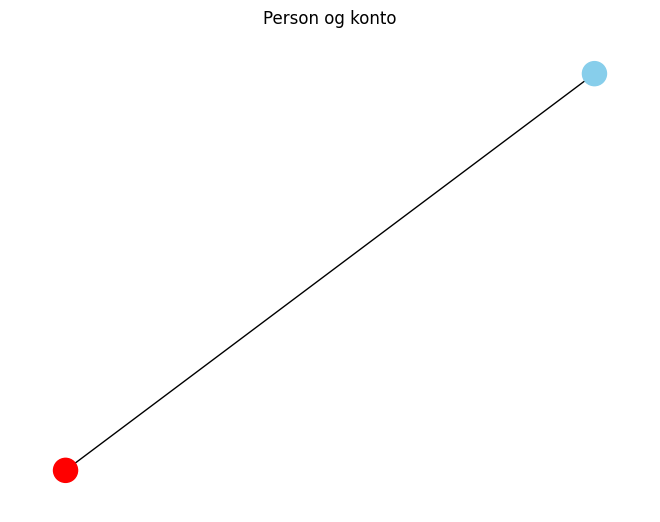

<Figure size 500x500 with 0 Axes>

In [5]:
# lage og tegne en person
G, uid, kto = lag_person_konto()

tegne_graf(G, "Person og konto")

In [6]:
# Gitt to personer, send penger.
#
def lag_overføring_person(G, fra_p, til_p, beløp, tidspunkt):
    assert(fra_p in G)
    assert(til_p in G)
    # Finn kontoene
    sender = None
    for u, v, attr in G.edges(fra_p, data=True):
        if attr.get("label") == ":Kontoeier":
            # Dette er kontoen
            sender = v
            break
        #
    #
    assert sender, f"Person {fra_p} har ingen konto"

    mottaker = None
    for u, v, attr in G.edges(til_p, data=True):
        if attr.get("label") == ":Kontoeier":
            # Dette er kontoen
            mottaker = v
            break
        #
    #
    assert mottaker, f"Person {til_p} har ingen konto"

    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               labels=":Transaksjon",
               Overføring = True,
               Fra = sender,
               Til = mottaker,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til sendende konto
    G.add_edge(sender, transId, label=":Fra")
    # ...og til mottakende konto
    G.add_edge(transId, mottaker, label=":Til")
    # Knytt transaksjonen til senderen
    G.add_edge(transId, fra_p, label=":Overføring")
    # ....og til mottakeren
    G.add_edge(transId, til_p, label=":Overføring")

    return transId
#

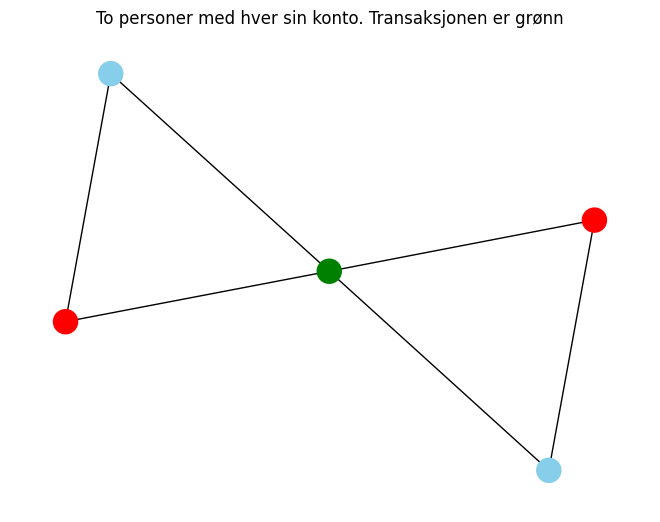

<Figure size 500x500 with 0 Axes>

In [7]:
# Lag to personer, send penger fra den ene til den andre, og lag en tegning

P1, Pid1, kto = lag_person_konto()
P2, Pid2, kto = lag_person_konto()
G = nx.MultiGraph()
G = nx.compose(G, P1)
G = nx.compose(G, P2)
nå = datetime.now()

trans = lag_overføring_person(G, Pid1, Pid2, 100, nå)
tegne_graf(G, "To personer med hver sin konto. Transaksjonen er grønn")

In [8]:
# En person tar ut penger fra en konto
def person_uttak(G, person, beløp, tidspunkt):
    assert(person in G)
   # Finn kontoen
    kto = None
    for u, v, attr in G.edges(person, data=True):
        if attr.get("label") == ":Kontoeier":
            # Dette er kontoen
            kto = v
            break
        #
    #
    assert kto, f"Person {person} har ingen konto"

    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               labels=":Transaksjon",
               Uttak = True,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til kontoen
    G.add_edge(kto, transId, label=":Uttak")
    # Knytt transaksjonen til eieren
    G.add_edge(transId, person, label=":Uttak")
    
    return transId
#    
    

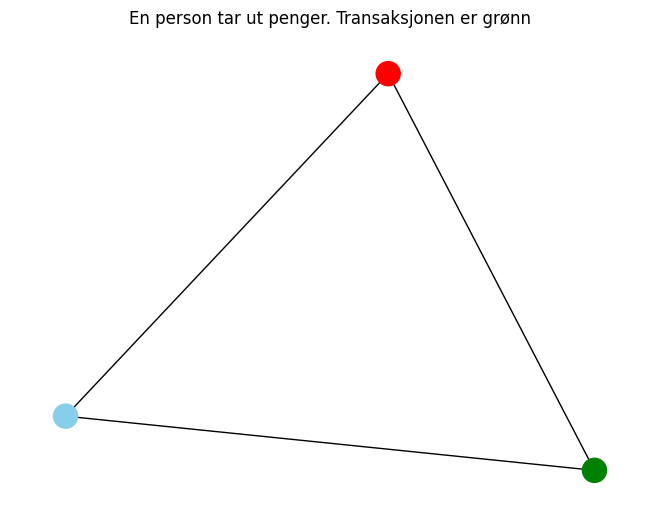

<Figure size 500x500 with 0 Axes>

In [9]:
# En person tar ut penger fra sin konto

P1, Pid1, kto = lag_person_konto()
G = nx.MultiGraph()
G = nx.compose(G, P1)
nå = datetime.now()

trans = person_uttak(G, Pid1, 100, nå)
tegne_graf(G, "En person tar ut penger. Transaksjonen er grønn")

In [10]:
# En person setter inn penger på sin konto
def person_innskudd(G, person, beløp, tidspunkt):
    assert person in G
   # Finn kontoen
    sender = None
    for u, v, attr in G.edges(person, data=True):
        if attr.get("label") == ":Kontoeier":
            # Dette er kontoen
            sender = v
            break
        #
    #
    assert sender, f"Person {person} har ingen konto"
    
    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               labels=":Transaksjon",
               Innskudd = True,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til mottakende konto
    G.add_edge(sender, transId, label=":Innskudd")
    # Knytt transaksjonen til eieren
    G.add_edge(transId, person, label=":Innskudd")
    
    return transId
#    

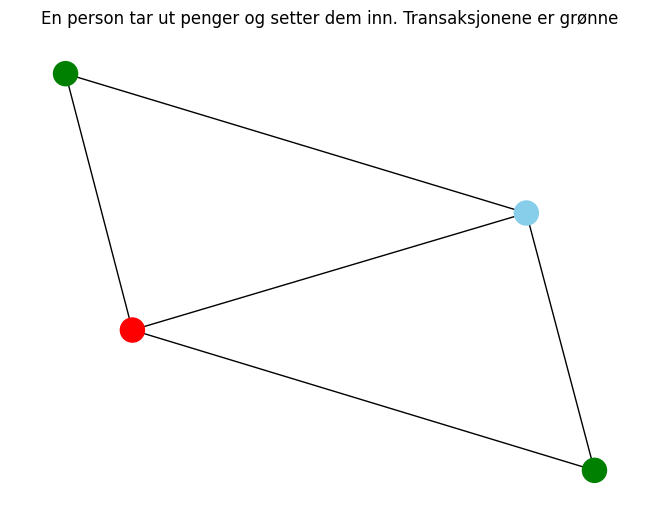

<Figure size 500x500 with 0 Axes>

In [11]:
# En person tar ut, og så setter inn penger

P1, Pid1, kto = lag_person_konto()
G = nx.MultiGraph()
G = nx.compose(G, P1)
nå = datetime.now()

trans = person_uttak(G, Pid1, 100, nå)
trans = person_innskudd(G, Pid1, 100, nå)
tegne_graf(G, "En person tar ut penger og setter dem inn. Transaksjonene er grønne")

## Kriminalitet

### "Money Mule"
Alle medlemmene i en klikk, unntatt én som vi kaller M, tar ut penger.  Deretter (i tid) setter Bakmannen, som M har relasjon til, et beløp som er noe mindre enn summen av det som er tatt ut.  Det endelige innskuddet skjer naturligvis en stund etter at alle uttakene er gjort.
Uttakene spres utover i tid (fra nå og fremover) og beløpet varierer opp til en grense.  M tar ikke ut penger (han får dem i kontanter).

Vi lager en klikk (og derfor en graf) og setter opp alle realsjonene.

In [12]:

def lag_money_mule(antall_personer, total_beløp):
    # Uttakene skjer innen dette vinduet
    vindu_uttak = 8 
    #ANtall dager senere innskuddet skjer
    når_skjer_innskuddet = 2
    
    # Lager personene og setter dem sammen til én graf, og lager så en klikk
    personer = nx.MultiGraph()
    folk = []
    konti = {}
    for i in range(antall_personer):
        person, uid, kto = lag_person_konto()
        konti[uid] = kto
        personer = nx.compose(personer, person)
        folk.append(uid) # Mennesker reduseres til UUID - slik er livet
    #
    # Lag subgraf av personene (ikke deres konti)
    S = personer.subgraph(folk)
    # Dette skaper en kopi
    S = nx.complete_graph(S, create_using=nx.MultiGraph())
    # Sett typen på kantene
    nx.set_edge_attributes(S, ":Kjenner", "label")
    # Dette gir oss én graf, bestående av konti + en klikk
    personer = nx.compose(personer, S)

    # Finn den som skal være forbryteren.
    M = random.choice(folk)
    print(f"Den skyldige er: {personer.nodes[M]["Navn"]}: {M}")

    # Legg til en bakmann med konto
    bakmann, bak_uid, bak_kto = lag_person_konto("Bakmann")
    personer = nx.compose(personer, bakmann)
    # M kjenner bakmannen
    personer.add_edge(M, bak_uid, label=":Kjenner")

    # Alle setter inn penger og sender dem til M
    bak_beløp = 0 # Totalt beløp tatt ut
    for person in folk:
        # Unntatt M, hen gjør noe annet
        if personer == M:
            print(f"Hopper over {M}")
            continue
        #
        beløp = round(total_beløp * random.random(), 2)
        tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random())
        t = person_innskudd(personer, person, beløp, tidspunkt)
        t = lag_overføring_person(personer, person, M, beløp, tidspunkt)
    #

    # M tar ut pengene
    tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random())
    t = person_uttak(personer, M, beløp, tidspunkt)

    # M fraker pengene til bakmannen, som setter dem inn
    # M får bonus

    tidspunkt = datetime.now() + timedelta(days=når_skjer_innskuddet)
    t = person_innskudd(personer, bak_uid, bak_beløp - round(bak_beløp * random.random() * 0.25, 2), tidspunkt)
    return personer
#fed



Den skyldige er: Lukas: 42ae5a32-5eb6-4359-aa71-79739ae086c3


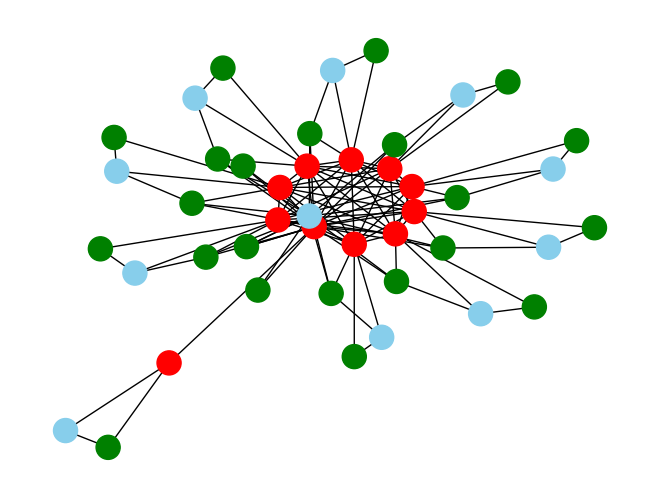

<Figure size 500x500 with 0 Axes>

In [13]:
#
# Lag og se
MM = lag_money_mule(10, 1000)
tegne_graf(MM)


In [14]:
#
G5 = lag_money_mule(5, 1000000)
G10 = lag_money_mule(10, 1000000)
G15 = lag_money_mule(15, 20000000) # 20 millioner

nx.write_graphml(G5, "grafer/Mule5.graphml")
nx.write_graphml(G10, "grafer/Mule10.graphml")
nx.write_graphml(G15, "grafer/Mule15.graphml")


Den skyldige er: Pelle: b484abe3-222f-4759-82a2-0c1af6fb292c
Den skyldige er: Preben: edd792f1-4c7d-4ebd-9cf5-899fff65317c
Den skyldige er: Benny: 1e4dae48-bb28-4b33-a13c-0a625b4e1c7b


### Bakmann
En som knytter sammen flere klikker

In [25]:
def bakmann_klikker(antall_klikker, antall_personer):
    # Antall_klikker er, vel, antall klikker
    # antall_personer er i hver klikk +- 25%
    assert(antall_klikker > 0)
    assert(antall_personer > 0)
    
    klikker = []
    for k in range(antall_klikker):
        klikk = nx.MultiGraph()
        folk = []
        # Litt variasjon i antall folk i hver klikk
        for i in range(antall_personer + int(antall_personer/4*random.uniform(-1, 1))):
            person, uid, _ = lag_person_konto()
            # Legg personen til i klikken
            klikk = nx.compose(klikk, person)
            folk.append(uid)
        #
        # Lag subgraf av personene (ikke deres konti)  En subgraf er et "view"
        S = klikk.subgraph(folk)
        # Konvertere til en klikk; operasjoen skaper en kopi
        S = nx.complete_graph(S, create_using=nx.MultiGraph)
        # Sett typen på kantene
        nx.set_edge_attributes(S, ":Kjenner", "label")
        # Slå dem sammen; networkx sikrer at det skjer som planlagt
        klikk = nx.compose(klikk, S)
        klikker.append(klikk)
    #
    
    # Her er bakmannen
    bakmann, bak_uid, _ = lag_person_konto("Bakmann")
    
    for klikk in klikker:
        # velg en node i klikken (trist å måtte konvertere klikken til en liste, men det er hva det er)
        folk = []
        for n, attr in klikk.nodes(data=True):
            if "labels" in attr:
                if attr["labels"] == ":Person":
                    folk.append(n)
                #
            #
        #
        medlem = random.choice(folk)
        # Ta inn klikken
        bakmann = nx.compose(bakmann, klikk)
        bakmann.add_edge(bak_uid, medlem, label=":Kjenner")
    #
    return(bakmann)
#fed


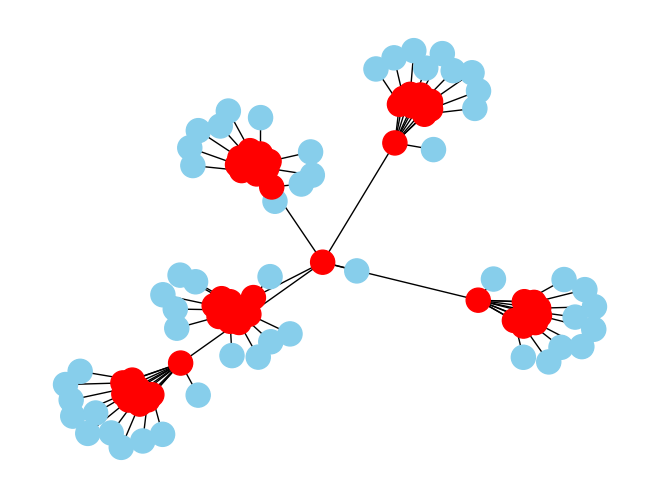

<Figure size 500x500 with 0 Axes>

In [26]:

G = bakmann_klikker(5, 10)
# Tegne
tegne_graf(G)


Lagre en graf med bakimann

In [28]:
B5 = bakmann_klikker(5, 10)
nx.write_graphml(B5, "grafer/Bakmann.graphml")


### Utbytte
Én stor transaksjon som tilsynelatende "spittes" i flere og sprer seg utover.  Det starter med ett stort innskudd av kontanter, som så spres utover flere personer.  Tiden går, samtidig som beløpet blir mindre

Dele en pengesum på et antall mennesker, mer eller mindre jevnt, innen et max og et min per person

For N personer, del beløpet opp i N-biter, pluss-minus 20%.  LEgg det som måtte være igjen til én av dem

In [36]:
def del_beløp(beløp, antall):
    penger = []
    igjen = beløp
    for p in range(antall):
        andel = beløp / antall * random.uniform(0.8, 1.2)
        if andel >= igjen:
            penger.append(round(igjen, 2))
            igjen = 0
        else:
            penger.append(round(andel, 2))
            igjen -= andel
        #
    #
    if igjen > 0:
        penger[0] += round(igjen, 2)
    #
    return penger
#


In [37]:

a = del_beløp(5000, 5)
print(a)
print(sum(a))

[1002.8799999999999, 1122.29, 986.1, 1039.75, 848.97]
4999.99


In [38]:
# Er beløpet mindre enn dette, da beholder du det
MINIMUM_BELØP = 5000
CUT = 15 # inntil, i prosent

# Denne er rekursiv
def del_utbyttet(G, bakmann, beløp, klokken):
    # Lag personen som nå skal bli bakmann
    person, uid, kto = lag_person_konto()
    NY = nx.compose(G, person)
    NY.add_edge(bakmann, uid, label = ":Kjenner")
    # Her kommer pengene
    lag_overføring_person(NY, bakmann, uid, beløp, klokken)
    
    if beløp < MINIMUM_BELØP:
        #print(f"Beløpet {beløp} deles ikke")
        #print(f"Slutter med {NY.number_of_edges()} kanter og {NY.number_of_nodes()} noder")
        return NY
    #
    
    beløp -= round(int(beløp * random.randint(1, CUT) / 100), 2)
    # Vi gjør jobben litt senere i dag
    nå = klokken + timedelta(days=random.random())
    # Hvor mange vi deler med avhenger av hvor stort beløpet er (logaritmisk, HEX)
    import math
    antall = round(math.log(beløp, 10))
    bøtter = del_beløp(beløp, antall)
    print(f"Beløpet {beløp} skal deles slik: {bøtter}")
    for b in bøtter:
        delt = del_utbyttet(NY, uid, b, nå)
        NY = nx.compose(NY, delt)
    #
    return NY
#fed


Vi lager en bakmann, deler opp beløpet, og kaller rekursivt til beløpet er b rukt opp

Beløpet 6580 skal deles slik: [1737.96, 1959.92, 1687.3, 1194.81]
MultiGraph with 18 nodes and 33 edges


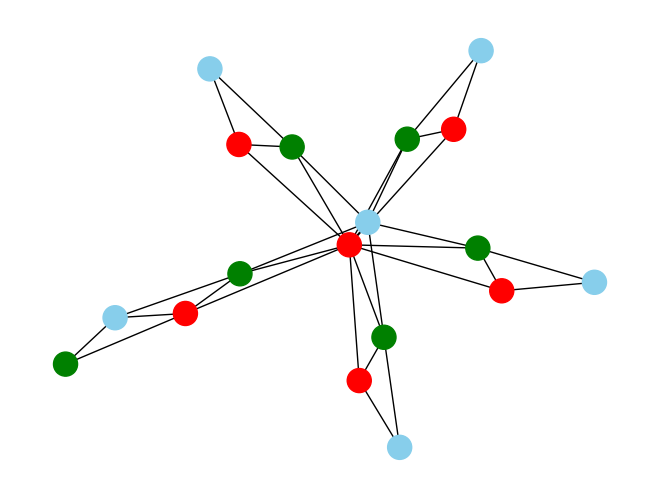

<Figure size 500x500 with 0 Axes>

In [39]:
BELØP = 7000
bakmann, b_uid, b_kto= lag_person_konto("Bakmann")
nå = datetime.now()
person_innskudd(bakmann, b_uid, BELØP, nå)
senere = nå + timedelta(hours=random.random())
G = del_utbyttet(bakmann, b_uid, BELØP, senere)
print(G)

# Tegne
tegne_graf(G)


Beløpet 59500 skal deles slik: [13699.09, 11993.02, 10689.82, 10353.48, 12764.59]
Beløpet 12193.09 skal deles slik: [3253.5800000000004, 3463.24, 2579.92, 2896.35]
Beløpet 11154.02 skal deles slik: [3837.3100000000004, 2431.87, 2650.8, 2234.04]
Beløpet 10048.82 skal deles slik: [2260.88, 2561.57, 2712.09, 2514.28]
Beløpet 9318.48 skal deles slik: [2324.65, 2172.34, 2377.63, 2443.87]
Beløpet 12637.59 skal deles slik: [3480.2400000000002, 2916.09, 2945.26, 3296.0]


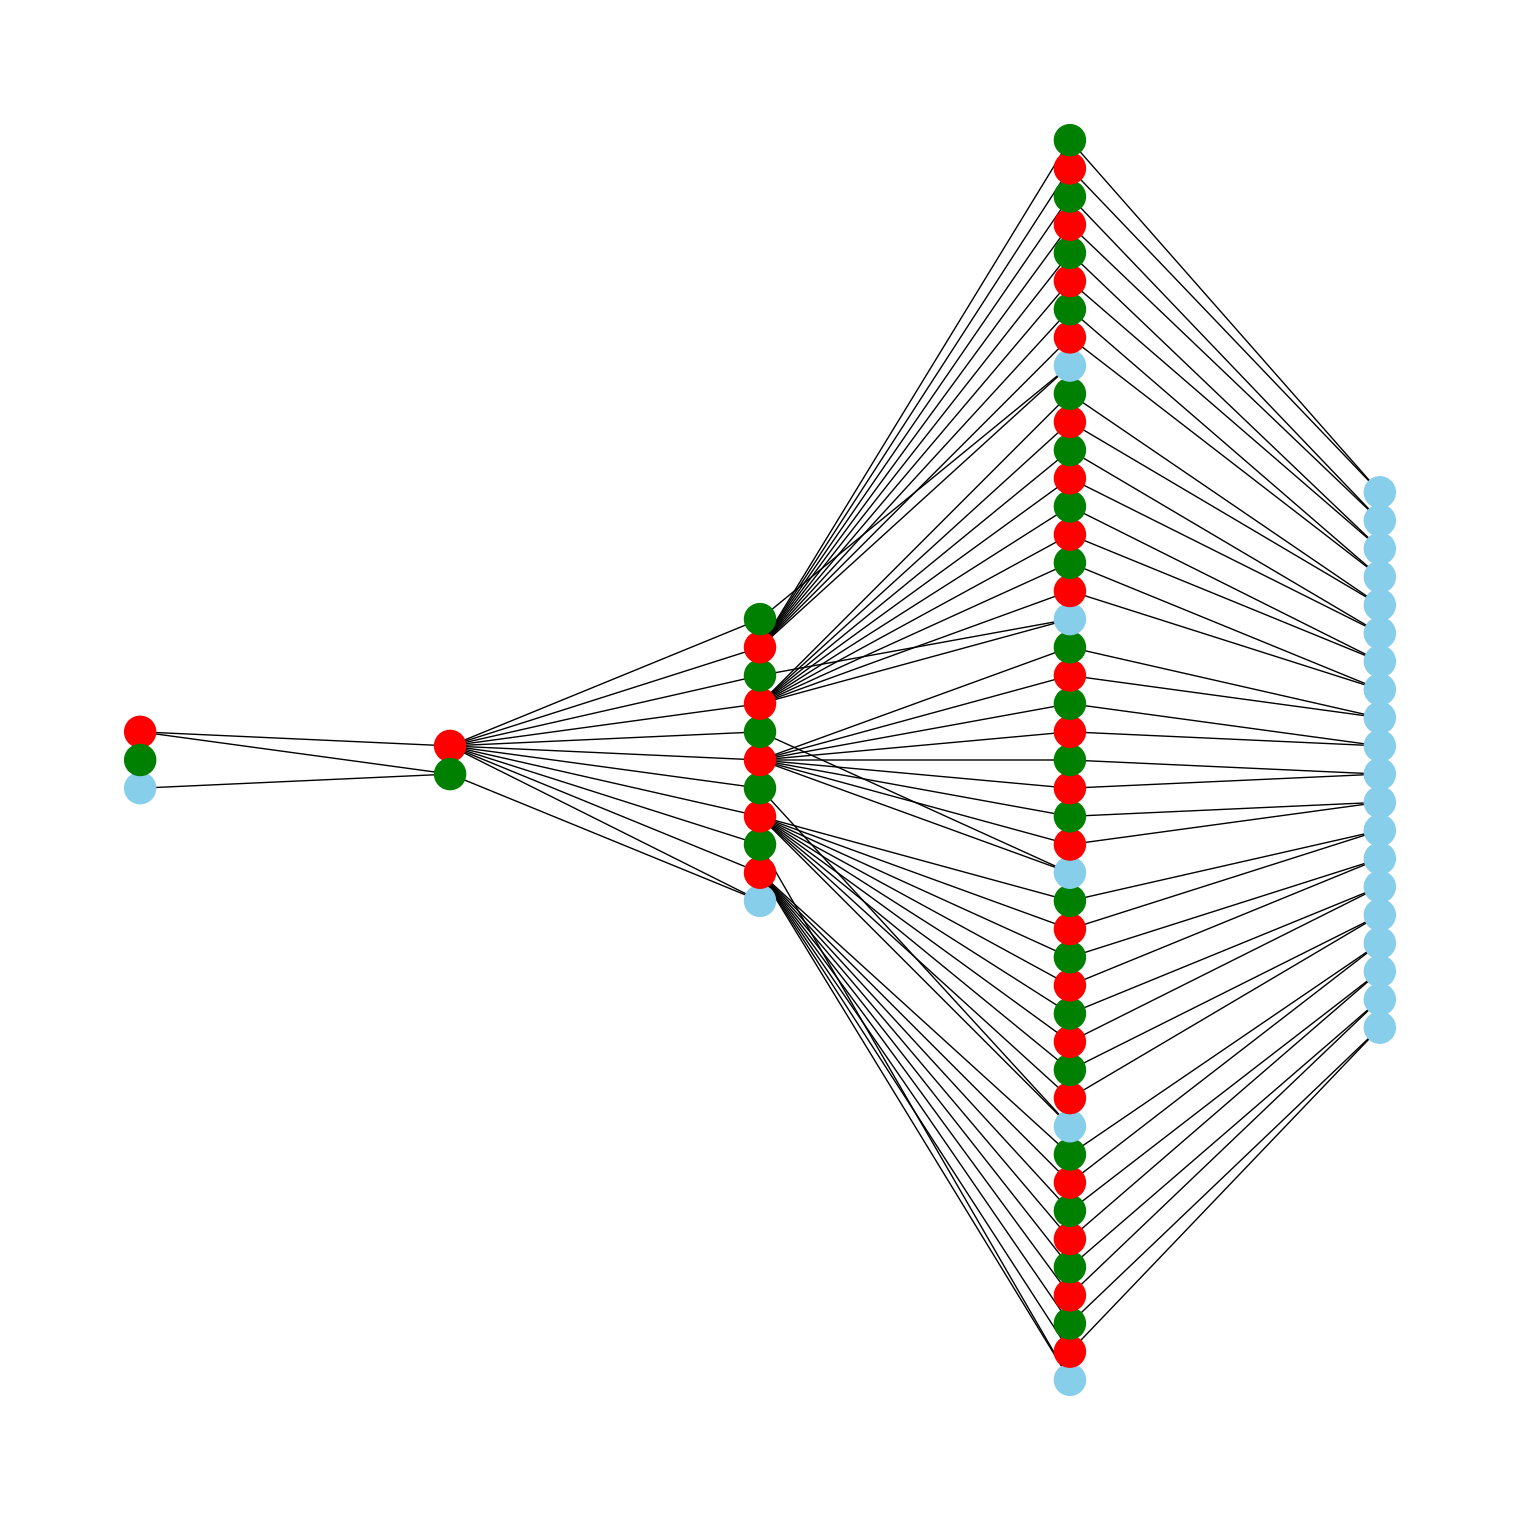

In [40]:
BELØP = 70000
bakmann, b_uid, b_kto= lag_person_konto("Bakmann")
nå = datetime.now()
person_innskudd(bakmann, b_uid, BELØP, nå)
senere = nå + timedelta(hours=random.random())
G = del_utbyttet(bakmann, b_uid, BELØP, senere)

node_farge = []
for n,d in G.nodes(data=True):
    if ":Person" == d["labels"]:
        node_farge += ["red"]
    elif ":Konto" == d["labels"]:
        node_farge += ["skyblue"]
    elif ":Uttak" == d["labels"]:
        node_farge += ["yellow"]
    elif ":Innskudd" == d["labels"]:
        node_farge += ["black"]
    elif ":Transaksjon" == d["labels"]:
       node_farge += ["green"]
    else:
        print(f"Node: {d['labels']}")
        node_farge += ["cyan"]
    #
#
pos = nx.bfs_layout(G, start=bakmann)
plt.figure(figsize=(15, 15))

nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=500)
plt.show()

In [41]:
BELØP = 70000
bakmann, b_uid, b_kto= lag_person_konto("Bakmann")
nå = datetime.now()
person_innskudd(bakmann, b_uid, BELØP, nå)
senere = nå + timedelta(hours=random.random())
G = del_utbyttet(bakmann, b_uid, BELØP, senere)
print(G)
nx.write_graphml(G, "grafer/Utbytte.graphml")


Beløpet 63700 skal deles slik: [14688.48, 14826.37, 14569.52, 12274.53, 7341.11]
Beløpet 13660.48 skal deles slik: [4085.89, 2891.71, 3836.19, 2846.7]
Beløpet 13937.37 skal deles slik: [3354.21, 2907.1, 3630.73, 4045.34]
Beløpet 13404.52 skal deles slik: [3291.22, 3596.54, 2731.92, 3784.84]
Beløpet 11170.53 skal deles slik: [3005.15, 3215.39, 2307.0, 2642.99]
Beløpet 6314.11 skal deles slik: [1767.0, 1313.46, 1355.47, 1878.18]
MultiGraph with 81 nodes and 159 edges
